In [12]:
#BNB stuff 
import pandas as pd
import numpy as np

In [6]:
eeg = pd.read_csv("../Data/eeg_features.csv")
transactions = pd.read_csv("../Data/transactions.csv")


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.metrics import accuracy_score

X = eeg[[
    "A31_spec_entropy",
    "C27_spec_entropy",
    "C6_spec_entropy",
    "H11_spec_entropy",
    "D18_spec_entropy",
    "H12_spec_entropy",
    "H17_spec_entropy",
    "H10_spec_entropy",
    "F18_spec_entropy",
    "H16_spec_entropy",
    "H22_spec_entropy",
    "H5_spec_entropy",
    "F29_spec_entropy",
    "D10_spec_entropy",
    "F16_spec_entropy",
    "H13_spec_entropy",
    "B8_spec_entropy",
    "F27_spec_entropy",
    "B2_spec_entropy"
]]
y = np.where(eeg["C4_bp_delta"] > eeg["C4_bp_delta"].median(), 1, 0)

#train-test
X_train, X_test, y_train, y_test_multi = train_test_split(X, y, test_size=0.25)

model = MultinomialNB()

model.fit(X_train, y_train)

preds_multi = model.predict(X_test)

accuracy_score(y_test_multi, preds_multi)



0.4166666666666667

In [41]:
X = eeg[[
    "A31_spec_entropy",
    "C27_spec_entropy",
    "C6_spec_entropy",
    "H11_spec_entropy",
    "D18_spec_entropy",
    "H12_spec_entropy",
    "H17_spec_entropy",
    "H10_spec_entropy",
    "F18_spec_entropy",
    "H16_spec_entropy",
    "H22_spec_entropy",
    "H5_spec_entropy",
    "F29_spec_entropy",
    "D10_spec_entropy",
    "F16_spec_entropy",
    "H13_spec_entropy",
    "B8_spec_entropy",
    "F27_spec_entropy",
    "B2_spec_entropy"
]]
y = transactions["F4_bp_alpha"]
#train-test
X_train, X_test, y_train, y_test_gauss = train_test_split(X, y, test_size=0.25)

model = GaussianNB()

model.fit(X_train, y_train)

preds_gauss = model.predict(X_test)

accuracy_score(y_test_gauss, preds_gauss)

0.75

In [44]:
from sklearn.naive_bayes import BernoulliNB

X = transactions.drop(columns=["F4_bp_alpha", "Unnamed: 0"])
y = transactions["F4_bp_alpha"]
#train-test
X_train, X_test, y_train, y_test_bernoulli = train_test_split(X, y, test_size=0.25)

model = BernoulliNB()

model.fit(X_train, y_train)

preds_bernoulli = model.predict(X_test)

accuracy_score(y_test_bernoulli, preds_bernoulli)

0.7916666666666666

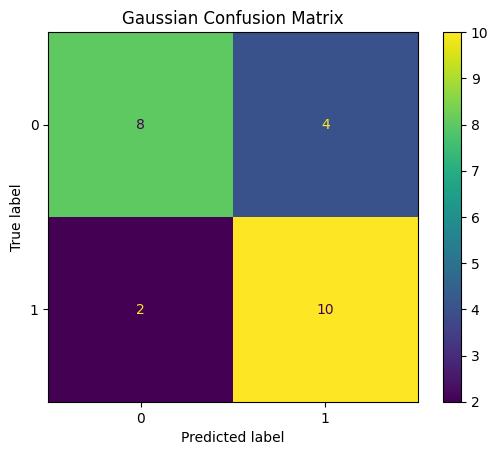

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_gauss, preds_gauss)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Gaussian Confusion Matrix")
plt.show()


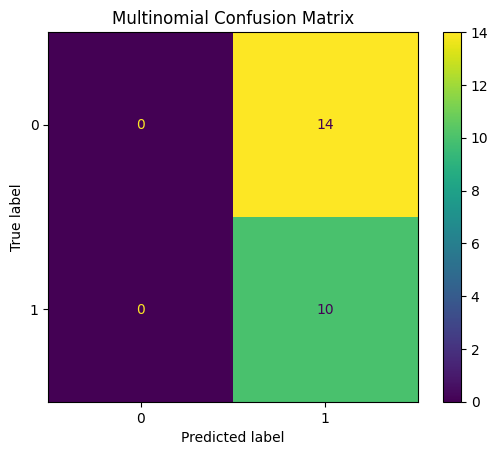

In [52]:
cm = confusion_matrix(y_test_multi, preds_multi)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Multinomial Confusion Matrix")
plt.show()

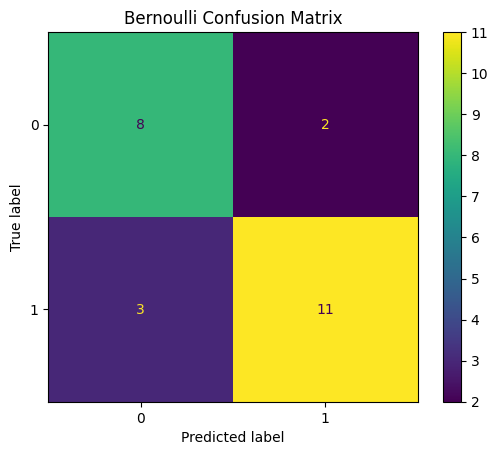

In [53]:
cm = confusion_matrix(y_test_bernoulli, preds_bernoulli)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Bernoulli Confusion Matrix")
plt.show()